In [1]:
import os
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

Imports:

In [2]:
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingRandomSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from typing import Callable, Dict
from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
from torch_geometric.loader import DataLoader
from scipy.stats import uniform, randint, loguniform
import yaml
from collections import Counter
from scipy.stats import pearsonr, spearmanr,entropy
import networkx as nx


from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset
from gjepa.datasets.graph_level import load_graph
from gjepa.config import GraphLevelExperimentConfig
from gjepa.utils.pyg import create_transform
from gjepa.utils.graph_level import split_dataset


/home/tymek/studies_AI/spectoChem/spectochem_ennv/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/tymek/studies_AI/spectoChem/spectochem_ennv/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN2at4_ops11multinomial4callERKNS_6TensorElbSt8optionalINS_9GeneratorEE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/tymek/studies_AI/spectoChem/spectochem_ennv/lib/python3.10/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/tymek/studies_AI/spectoChem/spectochem_ennv/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN2at4_ops11multinomial4callERKNS_6TensorElbSt8optionalINS_9GeneratorEE
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [19]:
tmqm_pair_dataset_config_path = "./config/dataset/TMQM_SPECTO_PAIRS.yaml" 

with open(tmqm_pair_dataset_config_path, 'r') as stream:
    pair_config = yaml.safe_load(stream)

pair_config['additional_loading_params']['num_states'] = 10
pair_config['additional_loading_params']['min_f_value'] = -1
print(pair_config)

{'name': 'TMQM_SPECTO', 'root_dir': 'data/datasets/TMQM_SPECTO', 'pre_transforms': {}, 'transforms': {'AddEdgesAndDistances': {'cutoff': 5.0}}, 'in_channels': 1, 'out_channels': 2, 'task_type': 'multiregression', 'split_ratios': [0.8, 0.1], 'block_3_split_mode': None, 'metric_mode': 'min', 'main_metric': 'MAE', 'additional_loading_params': {'prediction_type': 'pairs', 'num_states': 10, 'vis_range': [330, 650], 'block_3_only': True, 'filter_type': 'all_samples', 'min_f_value': -1, 'filter_f_value': -1, 'sort_by_max_f': False, 'standarize_lambda': True, 'standarize_f': True, 'load_representations': None, 'outlier_strategy': None, 'convert_to_ev': False, 'f_outlier_threshold': None, 'lambda_outlier_threshold': None}}


In [20]:
def get_dataset_for(config):
    return load_graph(
        root_dir=config['root_dir'],
        name=config['name'],
        additional_loading_params=config['additional_loading_params'],
        pre_transform=create_transform(config['pre_transforms']),
        transform=create_transform(config['transforms']))

In [21]:
binary_pair_dataset = get_dataset_for(pair_config)

Loading dataset 'TMQM_SPECTO' from data/datasets/TMQM_SPECTO...
{'prediction_type': 'pairs', 'num_states': 10, 'vis_range': [330, 650], 'block_3_only': True, 'filter_type': 'all_samples', 'min_f_value': -1, 'filter_f_value': -1, 'sort_by_max_f': False, 'standarize_lambda': True, 'standarize_f': True, 'load_representations': None, 'outlier_strategy': None, 'convert_to_ev': False, 'f_outlier_threshold': None, 'lambda_outlier_threshold': None}


Processing...


Merged dataset: 25893 rows (from 40111 base and 74273 star)


Processing: 100%|██████████| 25893/25893 [00:19<00:00, 1361.32it/s]


Positive classes: 0, Negative classes: 0


Done!


In [22]:
import os
print(os.path.exists("data/datasets/TMQM_SPECTO/processed"))

True


In [23]:
def pyg_dataset_info(dataset, max_examples=5):
    print(f"Number of graphs: {len(dataset)}")

    num_nodes, num_edges = [], []
    field_shapes = {}

    for i in range(min(len(dataset), max_examples)):
        data = dataset[i]
        num_nodes.append(data.num_nodes)
        num_edges.append(data.num_edges)

        for key, item in data:
            if hasattr(item, "shape"):
                field_shapes.setdefault(key, set()).add(tuple(item.shape))
            else:
                field_shapes.setdefault(key, set()).add(type(item))

    print(f"Average nodes: {sum(num_nodes)/len(num_nodes):.2f}")
    print(f"Average edges: {sum(num_edges)/len(num_edges):.2f}")
    print("\nFields and shapes (first few samples):")

    example_values = {}
    for i in range(min(len(dataset), max_examples)):
        data = dataset[i]
        for key, value in data:
            if key not in example_values:
                example_values[key] = []
            if isinstance(value, str):
                example_values[key].append(value)
            elif hasattr(value, "shape"):
                example_values[key].append(f"Tensor{tuple(value.shape)}")
            else:
                example_values[key].append(type(value).__name__)

    print("\nFields and example values:")
    for key, examples in example_values.items():
        print(f"  - {key}: {examples[:3]}")  

pyg_dataset_info(binary_pair_dataset)


Number of graphs: 25893
Average nodes: 71.20
Average edges: 1950.00

Fields and shapes (first few samples):

Fields and example values:
  - y: ['Tensor(1, 20)', 'Tensor(1, 20)', 'Tensor(1, 20)']
  - pos: ['Tensor(85, 3)', 'Tensor(74, 3)', 'Tensor(45, 3)']
  - z: ['Tensor(85,)', 'Tensor(74,)', 'Tensor(45,)']
  - smiles: ['Cc1ccc([B-]23c4cccc5[B-]6(c7ccc(C)cc7)n7cccn7->[Sc+3](<-n45)(<-n4cccn42)(<-n2cccn23)(<-n2cccn26)<-O2CCCC2)cc1', 'Cc12->[Sc+3]34567(<-[CH2-]c8ccccc8N->3(C)C)(<-[CH2-]c3ccccc3N->4(C)C)<-c13c->5([c-]->6(C)c->72C)CCCC3', '']
  - origin_id: ['VUCVUN', 'XIGZUM', 'DASFIQ']
  - CSD_code: ['VUCVUN', 'XIGZUM', 'DASFIQ']
  - edge_index: ['Tensor(2, 2172)', 'Tensor(2, 2344)', 'Tensor(2, 822)']
  - edge_weight: ['Tensor(2172,)', 'Tensor(2344,)', 'Tensor(822,)']


Firstly let focus on analysing the output:

In [24]:
binary_pair_train_ds, binary_pair_val_ds, binary_pair_test_ds = split_dataset(binary_pair_dataset, pair_config['split_ratios'])

In [ ]:
import numpy as np

def get_outputs_distribution(dataset, num_pairs=10):

    lambdas_flat = []
    f_values_flat = []

    lambda_rows = [[] for _ in range(num_pairs)]
    f_rows = [[] for _ in range(num_pairs)]

    for data in dataset:
        y = data.y.squeeze()

        if y.numel() % 2 == 0 and y.numel() > 1:

            pairs = y.reshape(-1, 2).cpu().numpy()

            lam = pairs[:, 0]
            f = pairs[:, 1]

            lambdas_flat.extend(lam.tolist())
            f_values_flat.extend(f.tolist())

            for i in range(min(num_pairs, len(lam))):
                lambda_rows[i].append(lam[i])
                f_rows[i].append(f[i])

        else:
            continue

    lambdas_flat = np.array(lambdas_flat)
    f_values_flat = np.array(f_values_flat)

    lambda_matrix = np.array(lambda_rows)
    f_matrix = np.array(f_rows)

    return f_values_flat, lambdas_flat, f_matrix, lambda_matrix

def draw_outputs_distribution(f_values, lambdas, bins_f=100, bins_lambdas=100):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(lambdas, bins=bins_lambdas)
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Count")
    plt.title("Distribution of Wavelengths")

    plt.subplot(1, 2, 2)
    plt.hist(f_values, bins=bins_f, color="green")
    plt.xlabel("Oscillator Strength f")
    plt.ylabel("Count")
    plt.title("Distribution of f")
    plt.xlim(0, 2)  
    plt.tight_layout()

    plt.show()

def draw_outputs_distribution_filtered(f_values, lambdas, bins_f=100, bins_lambdas=100, min_f_values=0.2):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    mask = f_values >= min_f_values
    f_filtered = f_values[mask]
    lambdas_filtered = lambdas[mask]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(lambdas_filtered, bins=bins_lambdas)
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Count")
    plt.title(f"Distribution of Wavelengths (f >= {min_f_values})")

    plt.subplot(1, 2, 2)
    plt.hist(f_filtered, bins=bins_f, color="green")
    plt.xlabel("Oscillator Strength f")
    plt.ylabel("Count")
    plt.title(f"Distribution of f (f >= {min_f_values})")
    plt.xlim(min_f_values, 2)
    plt.tight_layout()

    plt.show()

def draw_space_covering(f_values, lambdas, s=10, bins=40):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    plt.figure(figsize=(6, 5))
    plt.scatter(lambdas, f_values, s=s, alpha=0.6, label="Samples")
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Oscillator Strength f")
    plt.title("Lambda vs f: Coverage of Output Space")

    bin_edges = np.linspace(lambdas.min(), lambdas.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    median_f = []
    max_f = []

    for i in range(bins):
        mask = (lambdas >= bin_edges[i]) & (lambdas < bin_edges[i + 1])
        if np.any(mask):
            median_f.append(np.median(f_values[mask]))
            max_f.append(np.max(f_values[mask]))
        else:
            median_f.append(np.nan)
            max_f.append(np.nan)

    plt.plot(bin_centers, median_f, color="red", linewidth=2, label="Median f")
    plt.plot(bin_centers, max_f, color="blue", linewidth=2, label="Max f")
    plt.legend()
    plt.tight_layout()
    plt.show()


def draw_boxplots(f_values, lambdas, min_f_val=0.2):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    mask = f_values >= min_f_val
    f_filtered = f_values[mask]
    lambdas_filtered = lambdas[mask]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.boxplot([lambdas, lambdas_filtered], tick_labels=["All", f"f >= {min_f_val}"])
    plt.title("Boxplot Lambda")

    plt.subplot(1, 2, 2)
    plt.boxplot([f_values, f_filtered], tick_labels=["All", f"f >= {min_f_val}"])
    plt.title("Boxplot f")

    plt.tight_layout()
    plt.show()


In [38]:
f_values1, lambdas1, f_matrix1, lambda_matrix1 = get_outputs_distribution(binary_pair_train_ds)
f_values2, lambdas2, f_matrix2, lambda_matrix2 = get_outputs_distribution(binary_pair_val_ds)
f_values3, lambdas3, f_matrix3, lambda_matrix3 = get_outputs_distribution(binary_pair_test_ds)

In [39]:
f_values1.shape

(207150,)

In [40]:
f_values = np.concatenate([f_values1, f_values2, f_values3])
lambdas = np.concatenate([lambdas1, lambdas2, lambdas3])

f_values

array([0.0008, 0.0037, 0.0116, ..., 0.0701, 0.0698, 0.0719],
      shape=(258930,))

In [41]:
f_matrix = np.concatenate([f_matrix1, f_matrix2, f_matrix3], axis=1)
lambda_matrix = np.concatenate([lambda_matrix1, lambda_matrix2, lambda_matrix3], axis=1)

In [42]:
f_matrix.shape, lambda_matrix.shape

((10, 25893), (10, 25893))

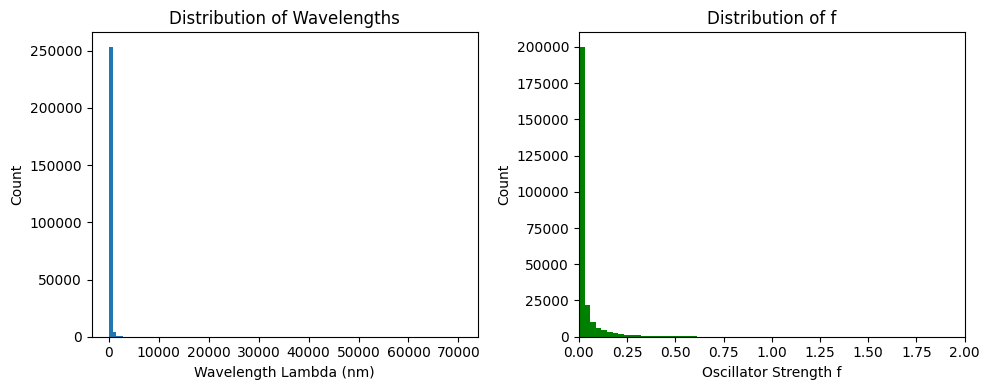

In [28]:
draw_outputs_distribution(f_values, lambdas)

In [ ]:
import numpy as np
import pandas as pd


def analyze_upper_outliers(values, name="variable"):
    values = np.asarray(values)
    n = len(values)

    results = []

    mean = np.mean(values)
    std = np.std(values)

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    for k in [2, 2.5, 3, 4, 5]:
        threshold = mean + k * std
        mask = values > threshold

        results.append({
            "variable": name,
            "method": f"mean + {k}*std",
            "threshold": threshold,
            "n_outliers": mask.sum(),
            "percent_outliers": mask.sum() / n * 100
        })

    for k in [1.5, 2, 2.5, 3, 4]:
        threshold = q3 + k * iqr
        mask = values > threshold

        results.append({
            "variable": name,
            "method": f"Q3 + {k}*IQR",
            "threshold": threshold,
            "n_outliers": mask.sum(),
            "percent_outliers": mask.sum() / n * 100
        })

    for p in [95, 97, 98, 99, 99.5, 99.9]:
        threshold = np.percentile(values, p)
        mask = values > threshold

        results.append({
            "variable": name,
            "method": f">{p} percentile",
            "threshold": threshold,
            "n_outliers": mask.sum(),
            "percent_outliers": mask.sum() / n * 100
        })

    return pd.DataFrame(results).sort_values("threshold")

In [30]:
f_table = analyze_upper_outliers(f_values, "f_values")
f_table

,variable,method,threshold,n_outliers,percent_outliers
5,f_values,Q3 + 1.5*IQR,0.061200,36085,13.936199
6,f_values,Q3 + 2*IQR,0.073300,31343,12.104816
7,f_values,Q3 + 2.5*IQR,0.085400,27570,10.647665
8,f_values,Q3 + 3*IQR,0.097500,24536,9.475920
9,f_values,Q3 + 4*IQR,0.121700,19862,7.670799
10,f_values,>95 percentile,0.177300,12946,4.999807
0,f_values,mean + 2*std,0.239456,8649,3.340285
11,f_values,>97 percentile,0.257313,7768,3.000039
1,f_values,mean + 2.5*std,0.290264,6431,2.483683
12,f_values,>98 percentile,0.334142,5179,2.000154


In [31]:
lambda_table = analyze_upper_outliers(lambdas, "lambdas")
lambda_table

,variable,method,threshold,n_outliers,percent_outliers
5,lambdas,Q3 + 1.5*IQR,582.619995,20171,7.790136
6,lambdas,Q3 + 2*IQR,644.929993,13731,5.302978
10,lambdas,>95 percentile,655.946509,12947,5.000193
7,lambdas,Q3 + 2.5*IQR,707.239990,10017,3.868613
11,lambdas,>97 percentile,760.976477,7768,3.000039
8,lambdas,Q3 + 3*IQR,769.549988,7487,2.891515
12,lambdas,>98 percentile,861.326788,5179,2.000154
9,lambdas,Q3 + 4*IQR,894.169983,4669,1.803190
0,lambdas,mean + 2*std,1131.508689,2669,1.030781
13,lambdas,>99 percentile,1147.135294,2590,1.000270


Pair index: 0


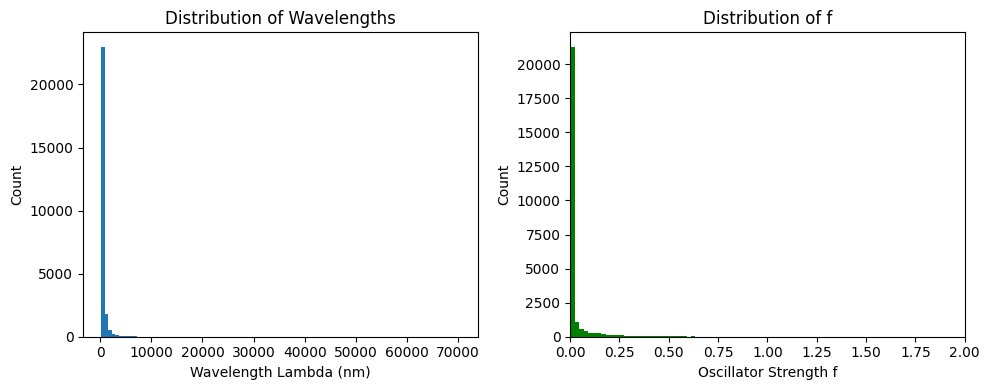

Pair index: 1


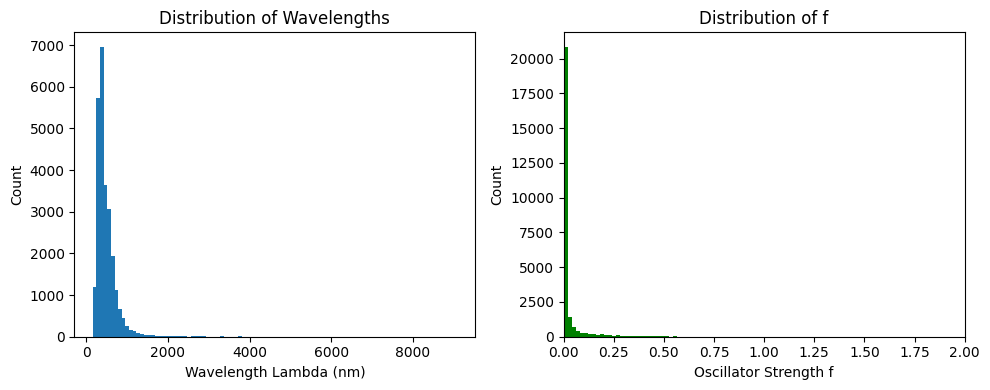

Pair index: 2


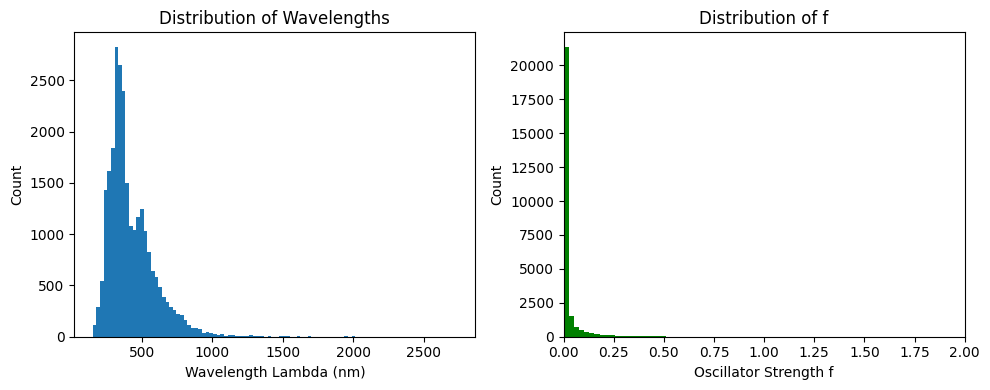

Pair index: 3


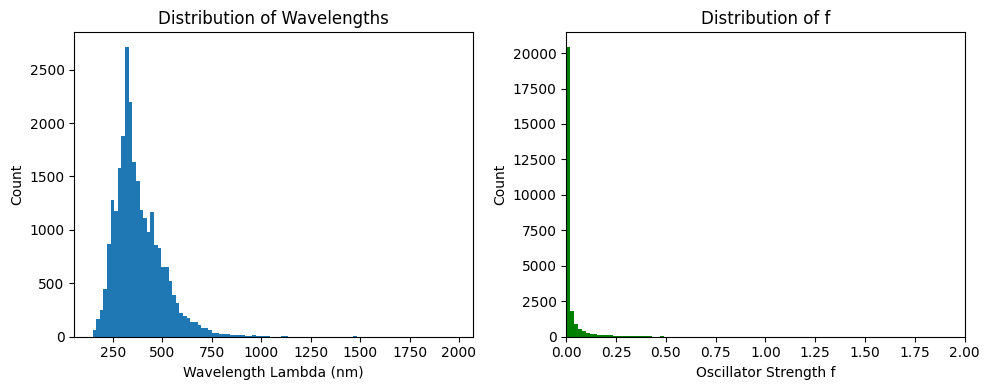

Pair index: 4


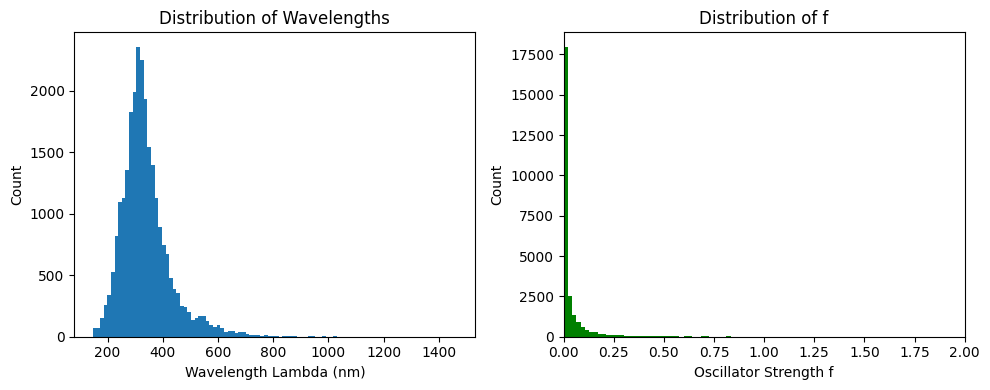

In [51]:
for idx, (f_, lambda_) in enumerate(zip(f_matrix, lambda_matrix)):
    print(f"Pair index: {idx}")
    draw_outputs_distribution(f_, lambda_)
    if idx >= 4:
        break

In [53]:
for idx, (f_, lambda_) in enumerate(zip(f_matrix, lambda_matrix)):
    print(f"Pair index: {idx}")
    print(analyze_upper_outliers(f_, "f_values"))
    print()
    if idx >= 4:
        break

Pair index: 0
    variable            method  threshold  n_outliers  percent_outliers
5   f_values      Q3 + 1.5*IQR   0.025450        4422         17.077975
6   f_values        Q3 + 2*IQR   0.030500        4095         15.815085
7   f_values      Q3 + 2.5*IQR   0.035550        3876         14.969297
8   f_values        Q3 + 3*IQR   0.040600        3671         14.177577
9   f_values        Q3 + 4*IQR   0.050700        3341         12.903101
10  f_values    >95 percentile   0.204340        1295          5.001352
0   f_values      mean + 2*std   0.270298         962          3.715290
11  f_values    >97 percentile   0.321368         777          3.000811
1   f_values    mean + 2.5*std   0.329159         758          2.927432
2   f_values      mean + 3*std   0.388020         573          2.212953
12  f_values    >98 percentile   0.406228         518          2.000541
3   f_values      mean + 4*std   0.505742         318          1.228131
13  f_values    >99 percentile   0.539200         

In [54]:
for idx, (f_, lambda_) in enumerate(zip(f_matrix, lambda_matrix)):
    print(f"Pair index: {idx}")
    print(analyze_upper_outliers(lambda_, "lambdas"))
    print()
    if idx >= 4:
        break

Pair index: 0
   variable            method     threshold  n_outliers  percent_outliers
5   lambdas      Q3 + 1.5*IQR   1028.274902        2073          8.006025
6   lambdas        Q3 + 2*IQR   1164.329956        1735          6.700653
7   lambdas      Q3 + 2.5*IQR   1300.385010        1458          5.630865
10  lambdas    >95 percentile   1385.024048        1295          5.001352
8   lambdas        Q3 + 3*IQR   1436.439941        1217          4.700112
9   lambdas        Q3 + 4*IQR   1708.549927         902          3.483567
11  lambdas    >97 percentile   1838.208252         777          3.000811
12  lambdas    >98 percentile   2374.649902         518          2.000541
0   lambdas      mean + 2*std   2740.896973         420          1.622060
1   lambdas    mean + 2.5*std   3269.128906         320          1.235855
13  lambdas    >99 percentile   3785.792236         259          1.000270
2   lambdas      mean + 3*std   3797.360596         257          0.992546
3   lambdas      mean + 

FOR LAMBDA AND F 1

# eV

In [66]:
def draw_outputs_distribution_ev(lambdas_ev, lambdas, bins_f=100, bins_lambdas=100):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.xlim(0, 2000)
    plt.hist(lambdas, bins=bins_lambdas, range=(0, 2000))
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Count")
    plt.title("Distribution of Wavelengths")

    plt.subplot(1, 2, 2)
    plt.hist(lambdas_ev, bins=bins_f, color="green")
    plt.xlabel("lambdas_ev (eV)")
    plt.ylabel("Count")
    plt.title("Distribution of f")
    plt.tight_layout()

    plt.show()

Pair index: 0


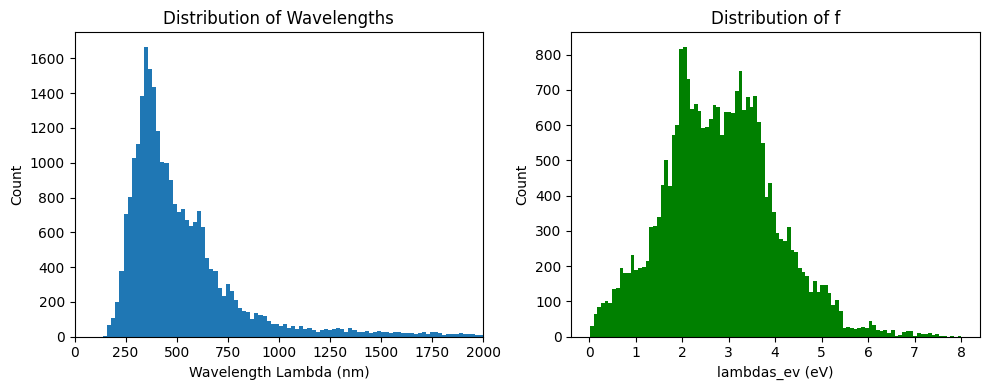

Pair index: 1


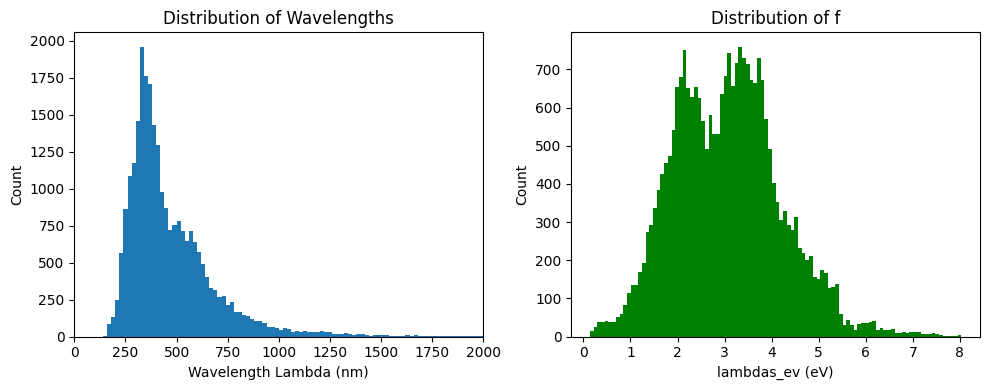

Pair index: 2


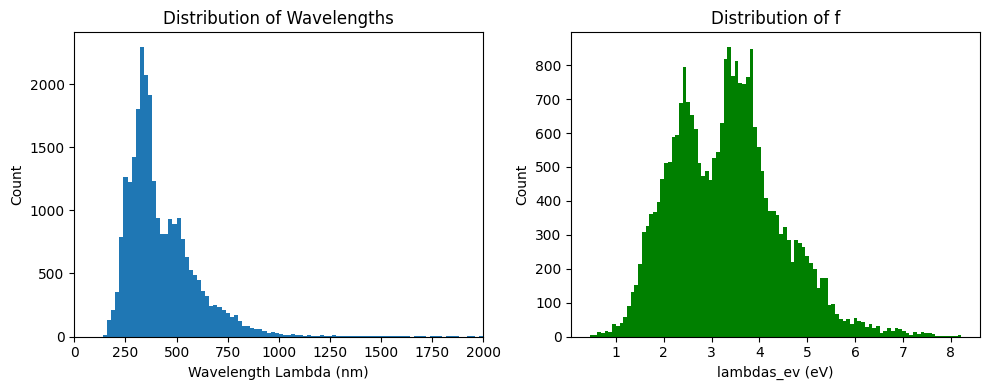

Pair index: 3


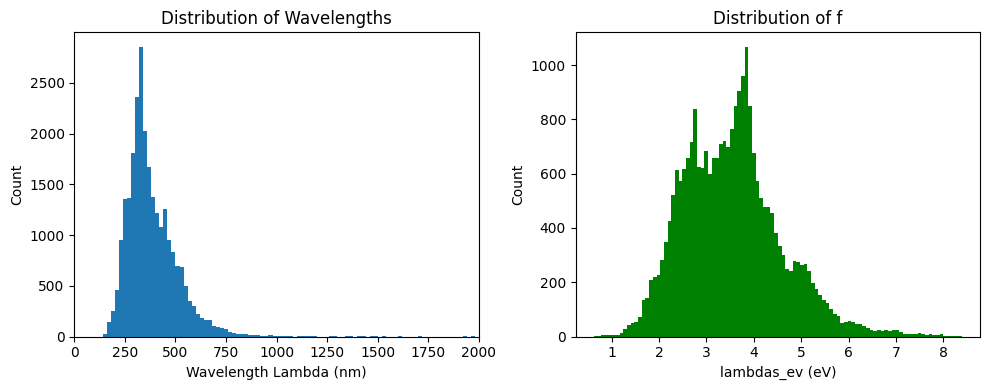

Pair index: 4


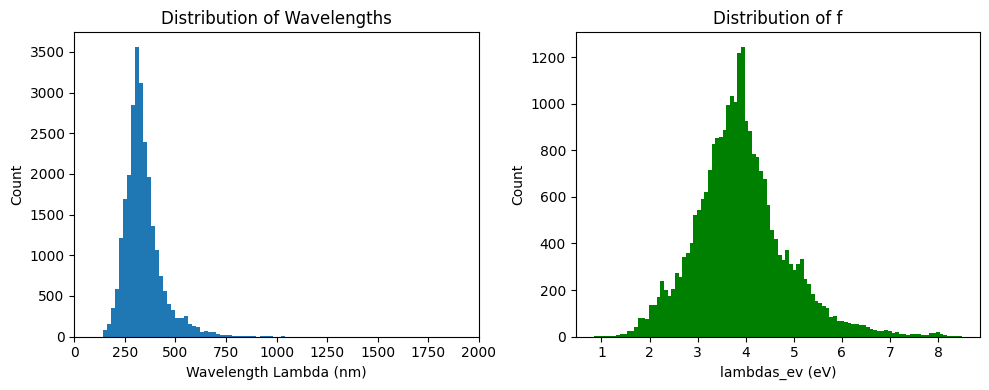

Pair index: 5


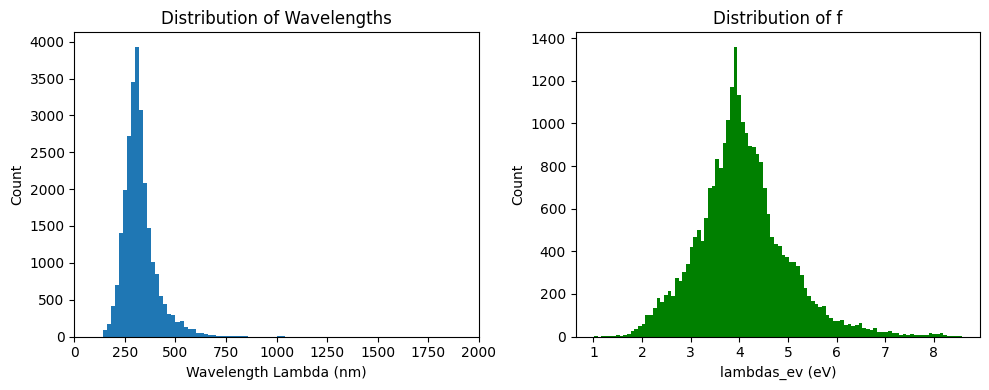

Pair index: 6


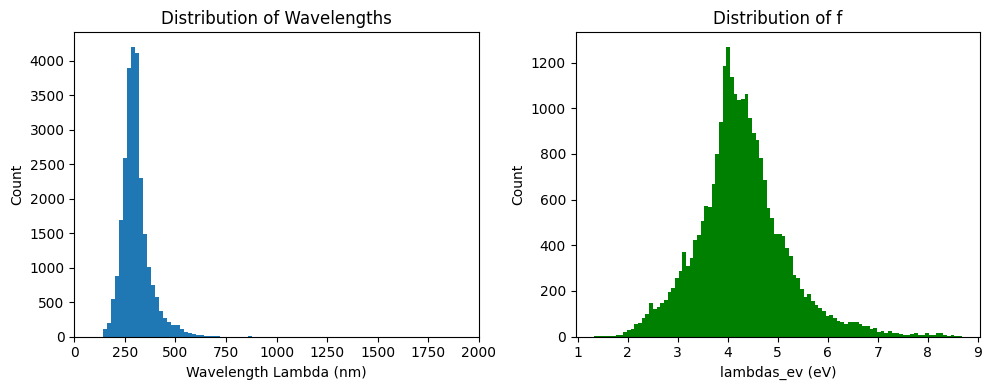

In [67]:
for idx, (f_, lambda_) in enumerate(zip(f_matrix, lambda_matrix)):
    print(f"Pair index: {idx}")
    lambda_ev = 1239.84 / lambda_
    draw_outputs_distribution_ev(lambda_ev, lambda_)
    if idx >= 6:
        break